<a href="https://colab.research.google.com/github/4GeeksAcademy/futabarentarou-data-clean-up-pandas-for-beginners-project/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from pickle import dump

import warnings
warnings.filterwarnings("ignore")

In [ ]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv"

df = pd.read_csv(url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("Shape:", df.shape)
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

Shape: (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


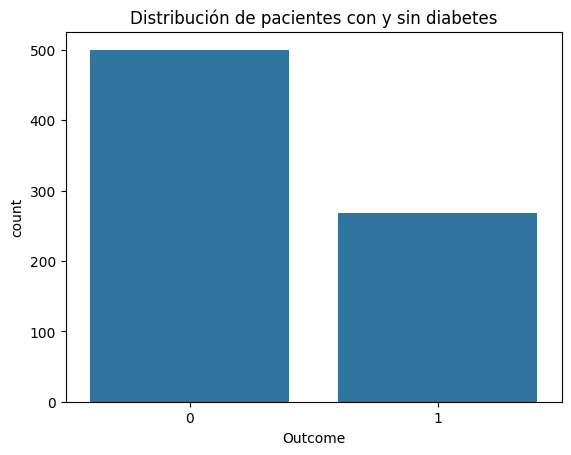

In [ ]:
df["Outcome"].value_counts()
sns.countplot(data=df, x="Outcome")
plt.title("Distribución de pacientes con y sin diabetes")
plt.show()

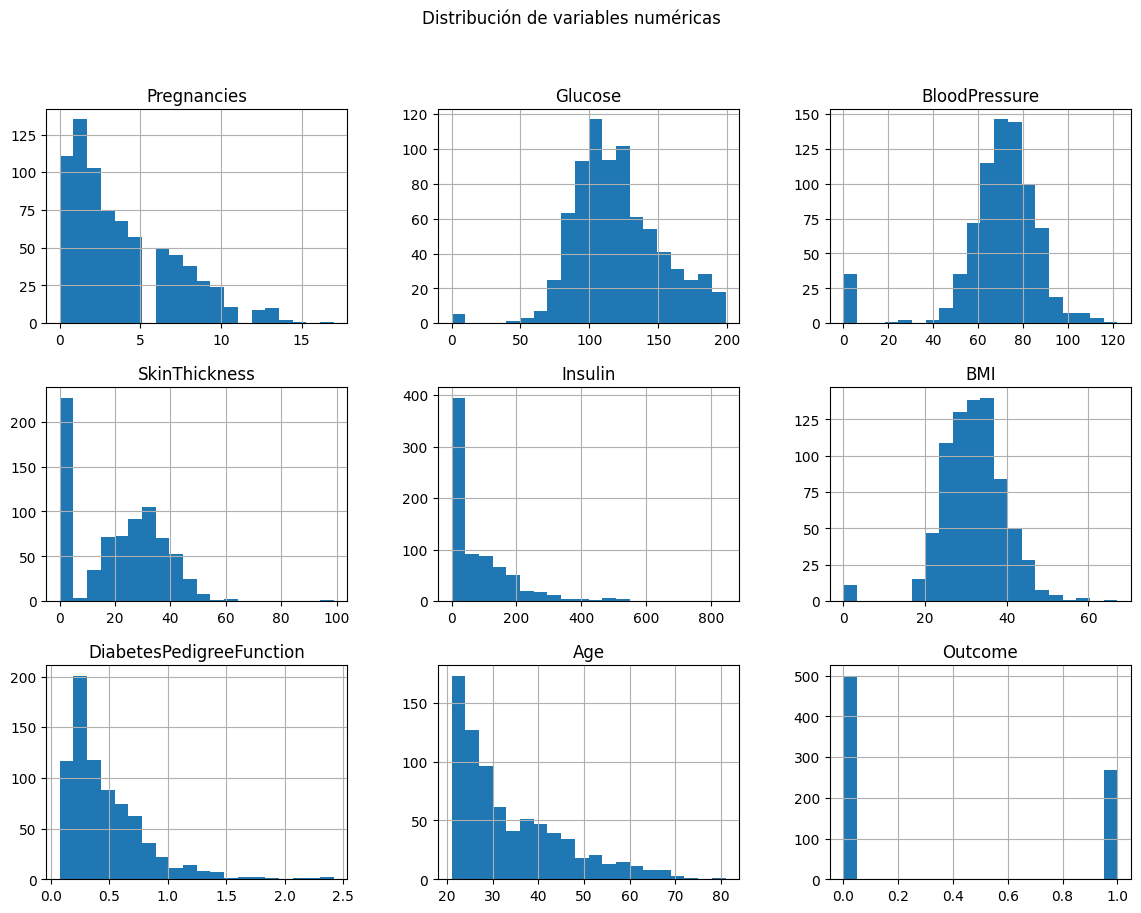

In [ ]:
df.hist(figsize=(14, 10), bins=20)
plt.suptitle("Distribución de variables numéricas")
plt.show()

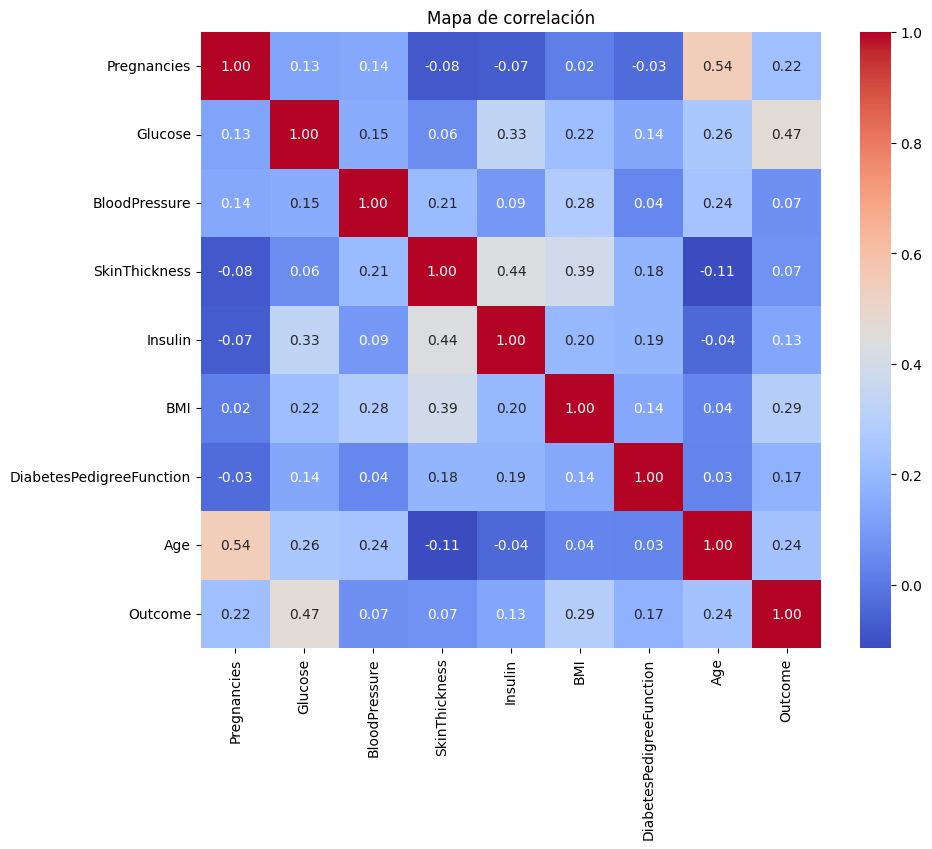

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Mapa de correlación")
plt.show()

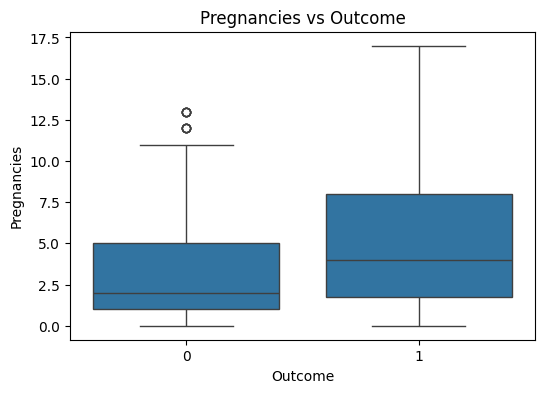

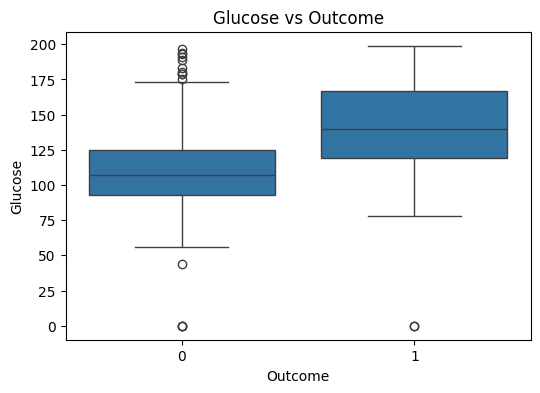

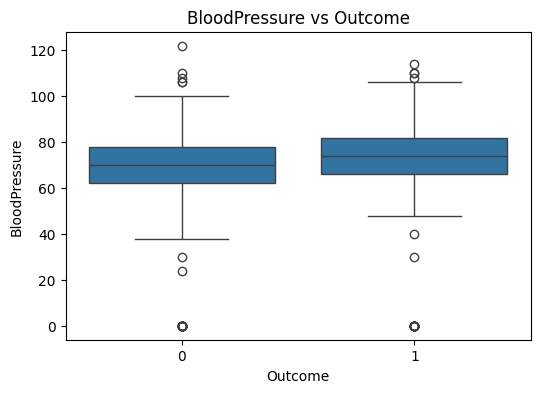

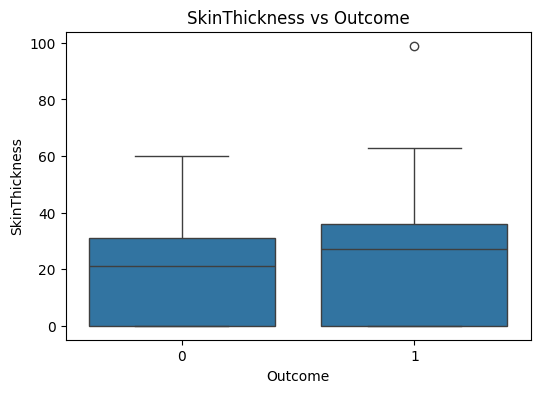

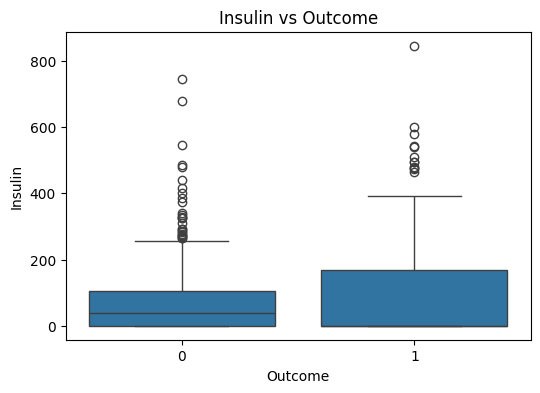

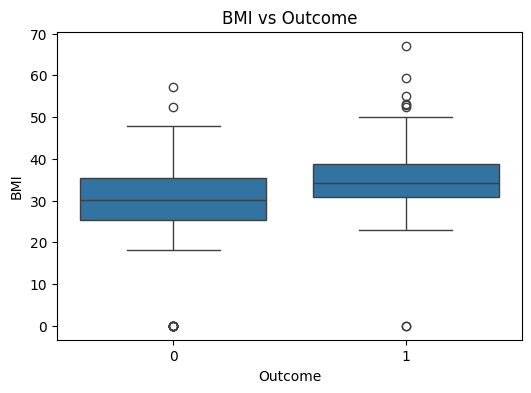

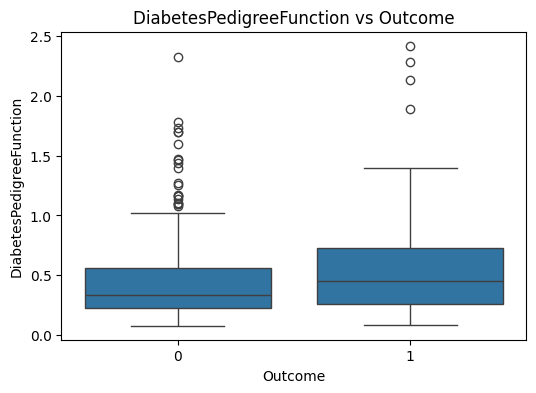

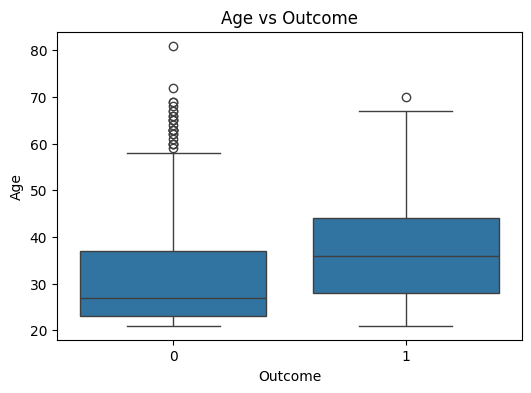

In [ ]:
features = df.drop("Outcome", axis=1).columns

for col in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="Outcome", y=col)
    plt.title(f"{col} vs Outcome")
    plt.show()

In [ ]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_columns:
    print(col, "zeros:", (df[col] == 0).sum())

Glucose zeros: 5
BloodPressure zeros: 35
SkinThickness zeros: 227
Insulin zeros: 374
BMI zeros: 11


In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
X.head()
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Accuracy Gini: 0.7272727272727273
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       100
           1       0.64      0.50      0.56        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.72      0.73      0.72       154



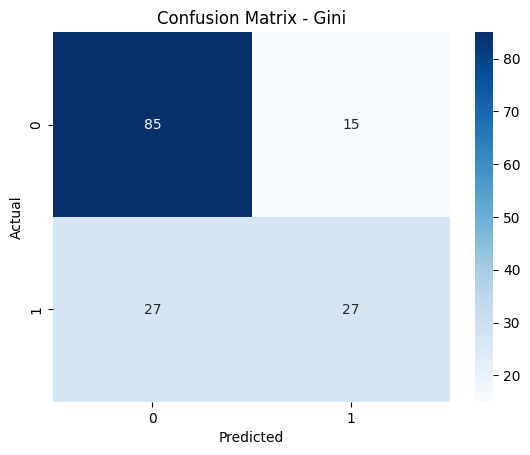

In [ ]:
tree_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

tree_gini.fit(X_train, y_train)

y_pred_gini = tree_gini.predict(X_test)

print("Accuracy Gini:", accuracy_score(y_test, y_pred_gini))
print(classification_report(y_test, y_pred_gini))

cm_gini = confusion_matrix(y_test, y_pred_gini)

sns.heatmap(cm_gini, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Gini")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
tree_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

tree_entropy.fit(X_train, y_train)

y_pred_entropy = tree_entropy.predict(X_test)

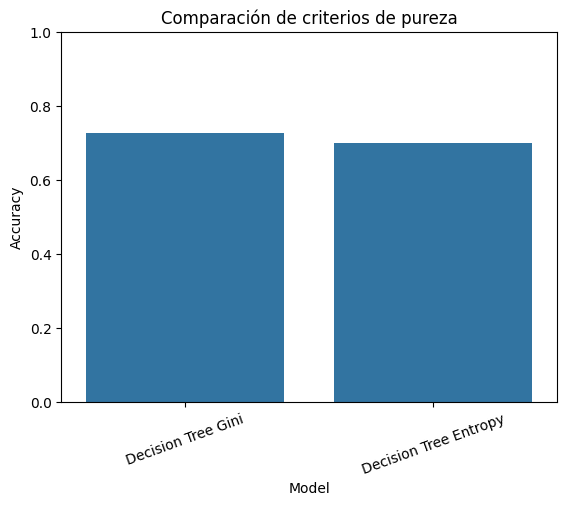

In [ ]:
results = pd.DataFrame({
    "Model": ["Decision Tree Gini", "Decision Tree Entropy"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_gini),
        accuracy_score(y_test, y_pred_entropy)
    ]
})

results

sns.barplot(data=results, x="Model", y="Accuracy")
plt.ylim(0, 1)
plt.title("Comparación de criterios de pureza")
plt.xticks(rotation=20)
plt.show()

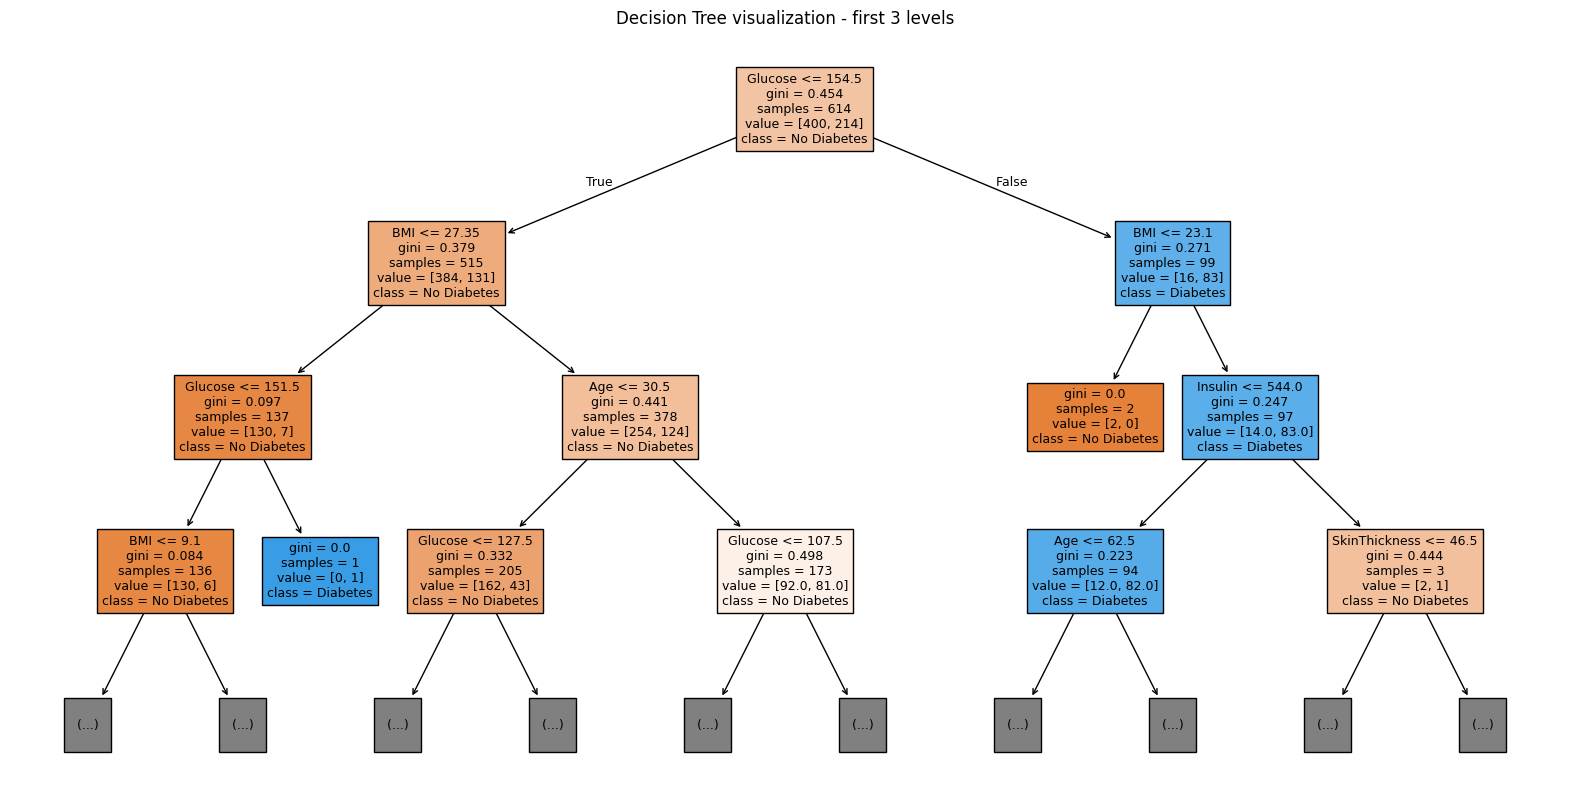

In [ ]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_gini,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    max_depth=3
)

plt.title("Decision Tree visualization - first 3 levels")
plt.show()

In [ ]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5],
    "min_samples_leaf": [1, 2, 4]
}

base_tree = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("Best CV score:")
print(grid_search.best_score_)

Best parameters:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 4}
Best CV score:
0.7459668420213613


In [ ]:
best_tree = grid_search.best_estimator_

best_tree.fit(X_train, y_train)

y_pred_best = best_tree.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy final:", accuracy_score(y_test, y_pred_best))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_best))

Accuracy final: 0.7012987012987013

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.70      0.93      0.80       100
           1       0.68      0.28      0.39        54

    accuracy                           0.70       154
   macro avg       0.69      0.60      0.60       154
weighted avg       0.70      0.70      0.66       154



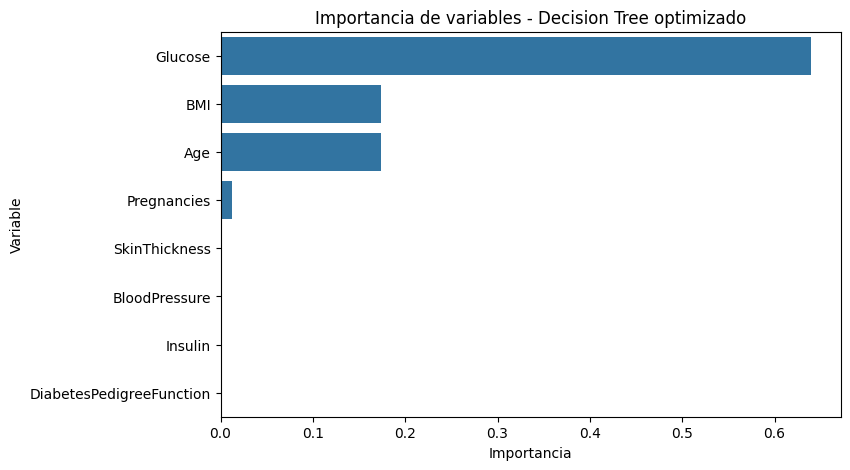

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": best_tree.feature_importances_
}).sort_values(by="Importancia", ascending=False)

feature_importance

plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de variables - Decision Tree optimizado")
plt.show()

In [ ]:
## Conclusiones

En este proyecto se construyó un modelo de clasificación utilizando un Decision Tree para predecir si un paciente presenta diabetes a partir de variables médicas.

Durante el análisis exploratorio de datos (EDA), se identificó que variables como Glucose, BMI, Age y DiabetesPedigreeFunction tienen una relación relevante con la variable objetivo (Outcome). También se detectaron valores en cero en algunas variables que podrían representar datos faltantes o mediciones poco realistas, lo cual es importante considerar en futuros análisis.

Se entrenaron modelos iniciales utilizando los criterios de pureza Gini y Entropy, observando diferencias en su desempeño. Posteriormente, se aplicó un proceso de optimización mediante GridSearchCV para encontrar la mejor combinación de hiperparámetros.

El modelo optimizado permitió mejorar el rendimiento general, controlando el sobreajuste mediante la limitación de la profundidad del árbol y el ajuste del número mínimo de muestras por nodo.

Finalmente, se analizaron las variables más importantes del modelo, lo que permite entender qué factores influyen más en la predicción, aportando interpretabilidad al resultado.

Este modelo demuestra cómo un Decision Tree puede capturar patrones relevantes en datos médicos y ofrecer una solución interpretable para problemas de clasificación binaria.